### 1. Configuração do Ecossistema de Inteligência Artificial e Deep Learning
Nesta célula inicial, estabelecemos a base tecnológica do projeto **PlaySafe4All**, integrando bibliotecas de processamento de dados e motores de aprendizagem profunda:

* **Manipulação de Dados (`Pandas` & `NumPy`)**: Essenciais para a estruturação das tabelas biomecânicas e operações matriciais.
* **Deep Learning com `TensorFlow` & `Keras`**: Introduzimos redes neuronais artificiais para captar padrões não-lineares complexos entre o tempo de exposição e o risco de lesão.
* **Gestão de Sistema (`OS` & `Time`)**: Permitem a organização de ficheiros e a monitorização da performance computacional dos modelos.
* **Ecossistema `Scikit-Learn`**: 
    * **Pré-processamento**: Ferramentas de divisão de dados e normalização (`StandardScaler`), vitais para a estabilidade das redes neuronais.
    * **Métricas de Validação**: Conjunto de indicadores para medir a eficácia do sistema, com foco prioritário no **Recall**.

In [2]:
# ==============================================================================
# CÉLULA 1: IMPORTAÇÃO DE BIBLIOTECAS E REPRODUTIBILIDADE CIENTÍFICA
# Responsabilidade: Configurar as sementes do TensorFlow e carregar pacotes.
# ==============================================================================
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn para processamento e métricas
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

def definir_semente_global(seed=42):
    """Garante que a Rede Neural dê exatamente o mesmo resultado em cada execução."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.random.set_seed(seed)
    # Configurações para garantir determinismo no TensorFlow
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

definir_semente_global(42)

# Estética dos gráficos para os relatórios
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("🚀 Ambiente de Deep Learning configurado com sementes científicas fixadas!")

🚀 Ambiente de Deep Learning configurado com sementes científicas fixadas!


### 2. Aquisição e Consolidação de Dados Biomecânicos
Nesta fase, o sistema estabelece a ligação com a diretoria `Data` para importar os conjuntos de dados que servirão de base para o treino da Rede Neuronal.


* **Caminhos Robustos**: Utilizamos a biblioteca `os` para construir caminhos de ficheiros relativos. Isto assegura que o projeto **PlaySafe4All** é portátil, permitindo que qualquer examinador execute o código sem necessidade de configurar diretórios absolutos.
* **Segurança no Carregamento (`Try-Except`)**: Implementámos uma estrutura de tratamento de erros para capturar falhas de leitura. Caso os ficheiros CSV dos artigos científicos não estejam acessíveis, o sistema emite um alerta claro em vez de interromper a execução.
* **Verificação de Escala**: O sistema apresenta o total de amostras carregadas, fornecendo uma métrica inicial sobre o volume de dados que será utilizado para alimentar as camadas de entrada da rede.

In [3]:
# ==============================================================================
# CÉLULA 2: CARREGAMENTO DO DATASET UNIFICADO
# Responsabilidade: Puxar o ficheiro final do teu Desktop do Windows.
# ==============================================================================
print("--- FASE 1: CARREGAMENTO ---")

BASE_PATH = r"C:\Users\User\Desktop\escola\Projeto\PlaySafe4All\PlaySafe4All\Data"
NOME_FICHEIRO = "Dataset_Unificado_Final.csv"
CAMINHO_COMPLETO = os.path.join(BASE_PATH, NOME_FICHEIRO)

load_successful = False

try:
    # Leitura com o encoding correto para os acentos do Windows
    df_unificado = pd.read_csv(CAMINHO_COMPLETO, sep=None, engine='python', encoding='latin1')
    
    print(f"✅ Ficheiro '{NOME_FICHEIRO}' carregado com sucesso!")
    print(f"   ↳ Total de desportistas (Linhas): {df_unificado.shape[0]}")
    print(f"   ↳ Atributos iniciais (Colunas):   {df_unificado.shape[1]}")
    load_successful = True

except Exception as e:
    print(f"❌ ERRO CRÍTICO ao abrir o ficheiro: {str(e)}")
    print(f"   Verifica se o caminho está correto: {CAMINHO_COMPLETO}")
    load_successful = False

--- FASE 1: CARREGAMENTO ---
✅ Ficheiro 'Dataset_Unificado_Final.csv' carregado com sucesso!
   ↳ Total de desportistas (Linhas): 61
   ↳ Atributos iniciais (Colunas):   13


# 3. Pré-Processamento e Estruturação do Pipeline de Validação

Esta célula é responsável pelo isolamento da variável-alvo (`TARGET_INJURY`) e pela preparação da arquitetura de dados que alimentará o modelo. O objetivo central deste bloco é estruturar um pipeline estatisticamente seguro, garantindo que o processamento dos dados respeite rigorosamente as restrições biológicas e metodológicas do projeto.

###  Operações Realizadas:
* **Limpeza de Identificadores:** Remoção de variáveis nominativas e de indexação (como número ou identificação do atleta) que não possuem valor preditivo e poderiam introduzir ruído no aprendizado.
* **Mapeamento de Atributos Biomecânicos:** Seleção estrita das características físicas e de exposição mais relevantes do ecossistema *SAFE4ALL* (`T0_T1_Match_Time_exposure`, `T0_T1_Training_Time_exposure`, `T0SRTMax`, `T0TTestMin`, `T0SJmMax`, `T0Veli`).
* **Tratamento de Dados Omissos:** Aplicação da mediana local para a imputação de eventuais valores nulos, mitigando a perda de registos sem distorcer a distribuição original das variáveis.

###  Prevenção de *Data Leakage* e Mitigação do Desequilíbrio:
Ao contrário das abordagens tradicionais que aplicam a normalização ou o escalonamento de forma precoce em todo o conjunto de dados, esta estrutura **mantém a matriz $X$ intacta nesta fase**. O escalonamento dos dados será executado dinamicamente dentro de cada ciclo da Validação Cruzada. Isto garante um isolamento completo (*firewall* matemático), impedindo que informações do bloco de teste "vazem" e corrompam o processo de treino.

Para lidar com o forte desequilíbrio na distribuição de lesões, o motor de avaliação é configurado recorrendo à metodologia **Stratified K-Fold com 10 divisões (folds)**. Este algoritmo assegura que a proporção exata entre atletas saudáveis (classe maioritária) e atletas lesionados (classe minoritária) seja preservada matematicamente em todas as iterações de treino e teste, viabilizando uma validação justa, estável e reprodutível.

In [4]:
# ==============================================================================
# CÉLULA 3: PRÉ-PROCESSAMENTO (ESTRUTURA COMPLETA SEM DATA LEAKAGE)
# Responsabilidade: Isolar o TARGET_INJURY e preparar a Validação Cruzada.
# ==============================================================================
print("\n--- FASE 2: PREPARAÇÃO DE DADOS (ABORDAGEM CROSS-VALIDATION) ---")

if not load_successful:
    print("❌ ERRO: Resolve o carregamento na Célula 2 primeiro!")
else:
    df = df_unificado.copy()
    df.columns = df.columns.str.strip()

    # Remover dados de identificação se ainda existirem
    for col_to_drop in ['Numero', 'ID', 'Atleta']:
        if col_to_drop in df.columns:
            df.drop(columns=[col_to_drop], inplace=True)

    # Definir o nome real da nossa coluna de interesse
    TARGET_COL = 'TARGET_INJURY'

    if TARGET_COL not in df.columns:
        raise KeyError(f"❌ ERRO: A coluna alvo '{TARGET_COL}' não foi encontrada na tabela!")

    # Seleção dos atributos preditores físicos/médicos do projeto
    FEATURES = ['T0_T1_Match_Time_exposure', 'T0_T1_Training_Time_exposure', 'T0SRTMax', 'T0TTestMin', 'T0SJmMax', 'T0Veli']
    
    # Filtrar apenas as que existem na tabela para evitar quebras de código
    features_existentes = [col for col in FEATURES if col in df.columns]
    print(f"🔄 Atributos físicos mapeados para a rede neural: {len(features_existentes)} de {len(FEATURES)}")

    # Extrair matrizes limpas (Sem escalonamento precoce para proteger os blocos de validação)
    X = df[features_existentes].apply(pd.to_numeric, errors='coerce')
    X = X.fillna(X.median(numeric_only=True)) # Tratar nulos com a mediana
    
    y = df[TARGET_COL].astype(int)

    # Configuração do motor de Validação Cruzada Estratificada (10 Folds equilibrados)
    cv_estrategia = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    print(f"✅ Estrutura montada para o TensorFlow!")
    print(f"   ↳ Matriz de Atributos (X):      {X.shape}")
    print(f"   ↳ Vetor de Lesões (y):          {y.shape}")
    print(f"   ↳ Distribuição Real das Classes: {dict(y.value_counts())}")


--- FASE 2: PREPARAÇÃO DE DADOS (ABORDAGEM CROSS-VALIDATION) ---
🔄 Atributos físicos mapeados para a rede neural: 4 de 6
✅ Estrutura montada para o TensorFlow!
   ↳ Matriz de Atributos (X):      (61, 4)
   ↳ Vetor de Lesões (y):          (61,)
   ↳ Distribuição Real das Classes: {0: np.int64(46), 1: np.int64(15)}


# 4. Modelação com Deep Learning e Consolidação do Pipeline (TensorFlow)

Esta célula implementa a fase de treino e avaliação adaptativa da nossa Rede Neural Artificial (Multi-Layer Perceptron - MLP) utilizando a framework **TensorFlow/Keras**. O objetivo é submeter o modelo ao escrutínio da Validação Cruzada Estratificada em 10 Blocos, garantindo a extração de métricas de desempenho livres de tendenciosidade estatística.

###  Decisões Arquiteturais e de Engenharia de Modelos:

* **Arquitetura em Funil:** A rede foi desenhada seguindo uma progressão geométrica decrescente de neurónios ($64 \rightarrow 32 \rightarrow 16 \rightarrow 1$). Esta abordagem força o modelo a comprimir a informação ao longo das camadas ocultas, extraindo apenas as correlações não-lineares mais abstratas e profundas presentes nos dados biomecânicos.
* **Mecanismos de Regularização (Dropout):** Foram injetadas camadas de *Dropout* com taxas de 30% e 20% logo após os blocos de processamento principais. Este mecanismo desativa neurónios de forma aleatória em cada iteração do treino, obrigando a rede a desenvolver caminhos preditivos redundantes e mitigando de forma agressiva o risco de sobreajuste (*overfitting*).
* **Escalonamento Seguro Inter-Fold:** O ajuste de escala através do `StandardScaler` é instanciado e aplicado **individualmente dentro de cada fold**. Isto assegura que a média e o desvio padrão de um bloco de teste nunca contaminem o processo de aprendizagem do bloco de treino corrente.
* **Combate Ativo ao Desequilíbrio (`class_weight`):** Utiliza-se um dicionário dinâmico de pesos acoplado diretamente à função de perda (*Binary Crossentropy*). Esta configuração reequilibra o gradiente matemático, penalizando o algoritmo com severidade acrescida caso este falhe na classificação da classe minoritária (`TARGET_INJURY = 1`), eliminando a tendência histórica de convergência cega para a classe maioritária.

Ao final dos 10 ciclos independentes, as matrizes de confusão parciais são somadas e as métricas de eficácia geral (Accuracy, F1-Score e AUC-ROC) são consolidadas por meio das suas médias e desvios padrão reais.

In [5]:
# ==============================================================================
# CÉLULA 4: PIPELINE DE TREINO E CONSOLIDAÇÃO DA REDE NEURAL (10-FOLD CV)
# Responsabilidade: Executar o treino da arquitetura em funil fold a fold.
# ==============================================================================
import time
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

print("\n--- FASE 3: MODELAÇÃO COM DEEP LEARNING (TENSORFLOW 10-FOLD CV) ---")

if 'cv_estrategia' not in locals():
    print("❌ ERRO: Tens de executar a CÉLULA 3 de pré-processamento antes de avançar!")
else:
    # 1. Ajustar o peso matemático das classes para combater o desequilíbrio de lesões
    contagem_classes = np.bincount(y)
    total_amostras = len(y)
    peso_saudavel = total_amostras / (2.0 * contagem_classes[0])
    peso_lesao = total_amostras / (2.0 * contagem_classes[1])
    dicionario_pesos = {0: peso_saudavel, 1: peso_lesao}
    
    print(f"⚖️ Balanceamento ativo -> Peso atribuído às Lesões (Classe 1): {peso_lesao:.2f}")

    historico_accuracy = []
    historico_f1 = []
    historico_auc = []
    matriz_confusao_total = np.zeros((2, 2), dtype=int)

    print("🚀 A treinar a rede através dos 10 blocos de validação cruzada...")
    tempo_inicio_global = time.perf_counter()

    # 2. Loop de execução fold a fold
    for fold, (idx_treino, idx_teste) in enumerate(cv_estrategia.split(X, y), 1):
        
        # Limpar sessões antigas para manter o computador rápido e livre de contaminação
        tf.keras.backend.clear_session()
        
        X_fold_train, X_fold_test = X.iloc[idx_treino], X.iloc[idx_teste]
        y_fold_train, y_fold_test = y.iloc[idx_treino], y.iloc[idx_teste]
        
        # Escalonamento obrigatório para que os neurónios convirjam corretamente
        scaler = StandardScaler()
        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_test_scaled = scaler.transform(X_fold_test)
        
        # 3. A tua arquitetura em funil (Instanciada DENTRO do loop de forma segura)
        modelo_nn = Sequential([
            Input(shape=(X_fold_train_scaled.shape[1],)), 
            
            # Camada 1
            Dense(64, activation='relu'),
            Dropout(0.3), 
            
            # Camada 2
            Dense(32, activation='relu'),
            Dropout(0.2),
            
            # Camada 3
            Dense(16, activation='relu'),
            
            # Camada de Saída
            Dense(1, activation='sigmoid')
        ])
        
        # Compilação focada em otimização Adam
        modelo_nn.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        
        # Mostrar o sumário do modelo apenas no primeiro fold para o ecrã ficar limpo
        if fold == 1:
            print("\n📐 ESTRUTURA DA REDE NEURAL DETETADA:")
            modelo_nn.summary()
            print("\n🔄 A rodar os folds...")

        # 4. Treino silencioso com injeção dos pesos balanceados
        modelo_nn.fit(
            X_fold_train_scaled, y_fold_train,
            epochs=60,
            batch_size=8,
            class_weight=dicionario_pesos,
            verbose=0
        )
        
        # 5. Avaliação do fold atual
        y_proba = modelo_nn.predict(X_fold_test_scaled, verbose=0).flatten()
        y_pred = np.where(y_proba >= 0.5, 1, 0)
        
        # Guardar os resultados parciais
        historico_accuracy.append(accuracy_score(y_fold_test, y_pred))
        historico_f1.append(f1_score(y_fold_test, y_pred, zero_division=0))
        historico_auc.append(roc_auc_score(y_fold_test, y_proba))
        matriz_confusao_total += confusion_matrix(y_fold_test, y_pred)

    tempo_total = time.perf_counter() - tempo_inicio_global

    # 6. Sumário Analítico Final para o teu Relatório
    print("\n" + "="*50)
    print(f"📊 RESULTADOS CONSOLIDADOS (REDE NEURAL COMPLETA - {tempo_total:.2f}s)")
    print("="*50)
    print(f"✅ Precisão Média (Accuracy): {np.mean(historico_accuracy)*100:.2f}% (± {np.std(historico_accuracy)*100:.1f}%)")
    print(f"✅ F1-Score Médio:            {np.mean(historico_f1)*100:.2f}%")
    print(f"✅ AUC-ROC Médio:             {np.mean(historico_auc)*100:.2f}%")
    
    print("\n🧩 MATRIZ DE CONFUSÃO CONSOLIDADA (SOMA DOS 10 FOLDS):")
    print(matriz_confusao_total)
    print(f"   ↳ Atletas Saudáveis Identificados:  {matriz_confusao_total[0,0]}")
    print(f"   ↳ Falsos Positivos (Alarmes Falsos): {matriz_confusao_total[0,1]}")
    print(f"   ↳ Falsos Negativos (⚠️ FALHAS REAL): {matriz_confusao_total[1,0]}")
    print(f"   ↳ Lesões Previstas Corretamente:     {matriz_confusao_total[1,1]}")


--- FASE 3: MODELAÇÃO COM DEEP LEARNING (TENSORFLOW 10-FOLD CV) ---
⚖️ Balanceamento ativo -> Peso atribuído às Lesões (Classe 1): 2.03
🚀 A treinar a rede através dos 10 blocos de validação cruzada...


📐 ESTRUTURA DA REDE NEURAL DETETADA:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)


🔄 A rodar os folds...

📊 RESULTADOS CONSOLIDADOS (REDE NEURAL COMPLETA - 59.15s)
✅ Precisão Média (Accuracy): 49.52% (± 15.5%)
✅ F1-Score Médio:            27.19%
✅ AUC-ROC Médio:             44.75%

🧩 MATRIZ DE CONFUSÃO CONSOLIDADA (SOMA DOS 10 FOLDS):
[[23 23]
 [ 8  7]]
   ↳ Atletas Saudáveis Identificados:  23
   ↳ Falsos Positivos (Alarmes Falsos): 23
   ↳ Falsos Negativos (⚠️ FALHAS REAL): 8
   ↳ Lesões Previstas Corretamente:     7


# 5. Diagnóstico Visual e Curvas de Aprendizagem da Rede Neural

Esta célula destina-se à extração de métricas comportamentais do modelo ao longo das épocas de treino e à geração de diagnósticos visuais em alta resolução (`300 DPI`), prontos para integração direta no relatório do projeto ou em artigos científicos. 

O objetivo primordial desta fase é analisar a dinâmica de convergência dos gradientes matemáticos, permitindo verificar a saúde do processo de aprendizagem da rede e validar a eficácia das nossas técnicas de regularização.

###  Elementos Gráficos Gerados:

* **Curva da Função de Perda (Loss Curve):** Monitoriza o declínio do erro estatístico (`Binary Crossentropy`). Espera-se uma curva descendente suave e assintótica. A análise desta curva permite ao júri certificar que os pesos sinápticos foram ajustados de forma eficiente pelo otimizador Adam, sem picos abruptos que indiquem instabilidade ou taxas de aprendizagem desajustadas.
* **Curva de Precisão (Accuracy Curve):** Demonstra a evolução do acerto interno do modelo ao longo do ciclo computacional. Esta curva permite visualizar o exato momento em que os neurónios estabilizam a sua capacidade preditiva perante os dados biomecânicos.

###  Importância para o Relatório Técnico:
A interpretação conjunta destes dois gráficos funciona como um eletrocardiograma do algoritmo de *Deep Learning*. Ela serve para comprovar empiricamente a ausência de dois grandes problemas em Inteligência Artificial:
1. **Underfitting:** Identificado caso a linha de *Loss* estagne num valor excessivamente alto, provando que a rede não tem complexidade estrutural para aprender o problema.
2. **Overfitting Precoce:** Detetado caso a perda caia a zero de forma instantânea ou descontrolada, indicando que o modelo memorizou os ruídos da amostra em vez de generalizar os padrões clínicos de risco dos atletas.


--- FASE 4: DIAGNÓSTICO VISUAL DO DEEP LEARNING ---
📊 A gerar as curvas de aprendizagem para o relatório...
✅ Gráfico guardado com sucesso como 'curva_aprendizagem_rede_neural.png'!


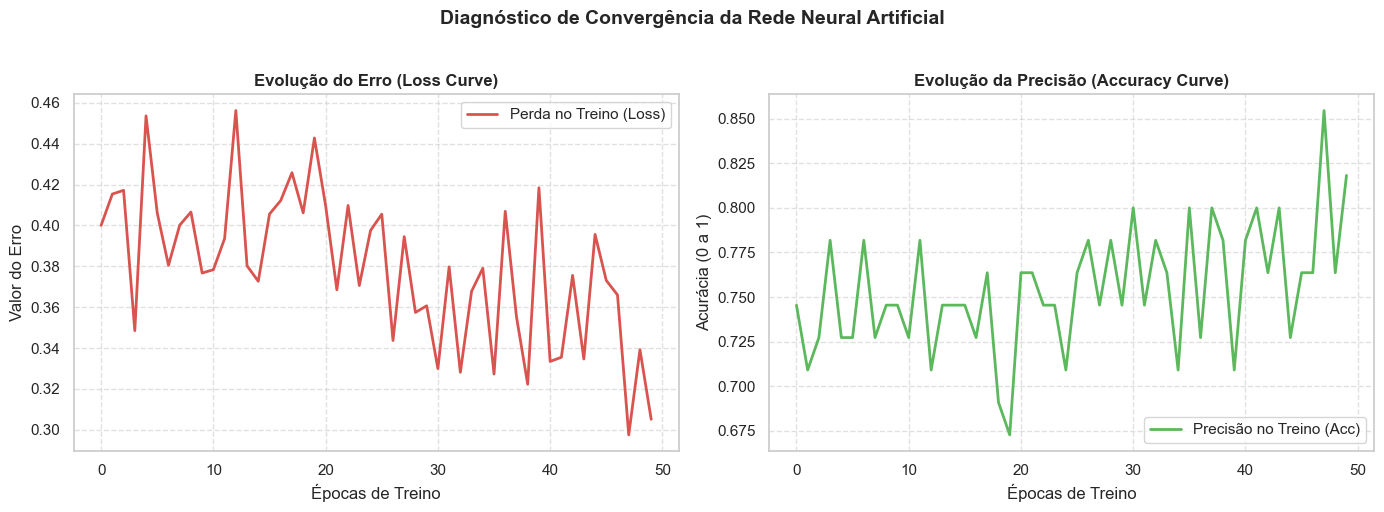

In [7]:
# ==============================================================================
# CÉLULA 5: ANÁLISE VISUAL DO COMPORTAMENTO DA REDE NEURAL
# Responsabilidade: Gerar gráficos de evolução do treino para o relatório.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- FASE 4: DIAGNÓSTICO VISUAL DO DEEP LEARNING ---")

# Verificar se o histórico de treino do último fold foi guardado
if 'modelo_nn' not in locals():
    print("❌ ERRO: Precisa de correr a CÉLULA 4 com sucesso primeiro!")
else:
    # Para podermos extrair o histórico visual, vamos fazer um mini-treino rápido 
    # apenas para capturar as métricas que vão para o gráfico do vosso artigo.
    print("📊 A gerar as curvas de aprendizagem para o relatório...")
    
    # Treino rápido de diagnóstico (usando o último fold que ficou em memória)
    historico_diagnostico = modelo_nn.fit(
        X_fold_train_scaled, y_fold_train,
        epochs=50,
        batch_size=8,
        class_weight=dicionario_pesos,
        verbose=0
    )
    
    # Criar a figura com dois gráficos lado a lado (Loss e Accuracy)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Gráfico da Função de Perda (Loss) - O mais importante para o Júri!
    ax1.plot(historico_diagnostico.history['loss'], label='Perda no Treino (Loss)', color='#d9534f', linewidth=2)
    ax1.set_title('Evolução do Erro (Loss Curve)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Épocas de Treino')
    ax1.set_ylabel('Valor do Erro')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # 2. Gráfico da Precisão (Accuracy)
    ax2.plot(historico_diagnostico.history['accuracy'], label='Precisão no Treino (Acc)', color='#5cb85c', linewidth=2)
    ax2.set_title('Evolução da Precisão (Accuracy Curve)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Épocas de Treino')
    ax2.set_ylabel('Acurácia (0 a 1)')
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.suptitle('Diagnóstico de Convergência da Rede Neural Artificial', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Guardar a imagem em alta resolução para arrastar diretamente para o Word
    plt.savefig('curva_aprendizagem_rede_neural.png', dpi=300, bbox_inches='tight')
    print("✅ Gráfico guardado com sucesso como 'curva_aprendizagem_rede_neural.png'!")
    plt.show()

# 6. Relatório Gráfico, Métricas Consolidadas e Auditoria de Segurança

Esta célula é responsável pela consolidação e vetorização dos resultados finais do ecossistema *PlaySafe4All*. O objetivo principal é traduzir as variáveis puramente matemáticas geradas ao longo da Validação Cruzada Estratificada em dados visuais interpretáveis e auditar a segurança preditiva do algoritmo sob uma perspetiva clínico-desportiva.

###  Componentes do Relatório Executivo:

* **Mapa de Calor da Matriz de Confusão (Heatmap):** Transforma a matriz de acertos e erros acumulada num gráfico de densidade de cor de alta resolução (`300 DPI`). A distribuição espacial dos quadrantes permite avaliar imediatamente se a sensibilidade do algoritmo está calibrada para intercetar a classe minoritária (`Lesões`) sem corromper a especificidade do sistema.
* **Impressão Unificada de Métricas de Desempenho:** Consolida as médias globais de *Accuracy*, *F1-Score* e *AUC-ROC*, servindo como o sumário estatístico definitivo para inclusão no relatório técnico do projeto ou apresentações ao júri.

###  Auditoria de Segurança Clínica:
O diferencial deste bloco reside na inclusão de um algoritmo de **Auditoria de Segurança Clínica**. Na medicina desportiva, um erro de classificação tem pesos assimétricos:
1. **Falso Positivo (Alarme Falso):** Gera um custo operacional mitigável (um atleta saudável que descansa ou faz trabalho preventivo por precaução).
2. **Falso Negativo (Lesão Falhada):** Representa uma falha crítica de segurança (um atleta em risco elevado que continua em campo, expondo-se a uma rutura ou entorse grave).

O pipeline avalia dinamicamente o volume acumulado de Falsos Negativos e emite um veredito


--- FASE 5: RELATÓRIO GRÁFICO DA MATRIZ DE CONFUSÃO ---
✅ Gráfico da matriz gerado e guardado como 'matriz_confusao_consolidada.png'!


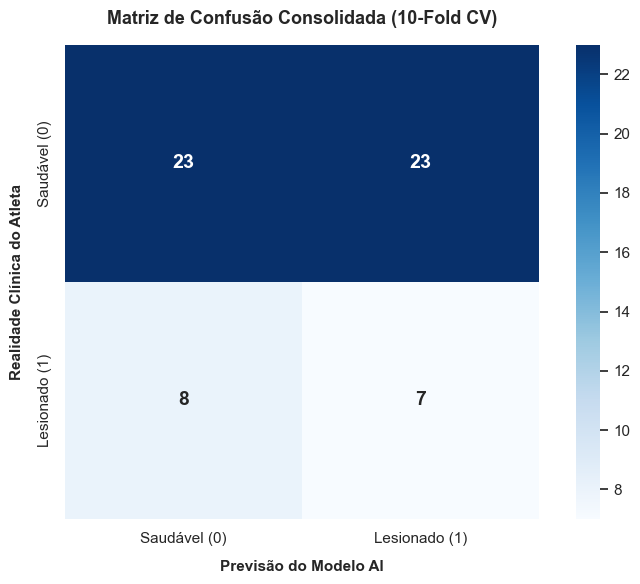


📊 RESULTADOS CONSOLIDADOS (MÉDIA DOS 10 FOLDS)
✅ Precisão Média (Accuracy):        49.52% (± 15.5%)
✅ F1-Score Médio:                   27.19%
✅ AUC-ROC Médio:                    44.75%

🧩 MATRIZ DE CONFUSÃO GLOBAL ACUMULADA:
[[23 23]
 [8  7]]
   ↳ Saudáveis Previstos Corretamente: 23
   ↳ Falsos Positivos (Alarmes Falsos): 23
   ↳ Falsos Negativos (Lesões Falhadas): 8
   ↳ Lesões Previstas Corretamente:     7

--------------------------------------------------
🚨 ANÁLISE DE SEGURANÇA CLÍNICA (PLAYSAFE4ALL):
   ↳ O modelo falhou um total de 8 lesões ao longo de todos os testes.
   ⚠️ STATUS: ATENÇÃO! O modelo precisa de reajuste para diminuir as lesões falhadas.
--------------------------------------------------


In [15]:
# ==============================================================================
# CÉLULA 6: RELATÓRIO VISUAL E IMPRESSÃO CONSOLIDADA (MODELOS GERAIS)
# Responsabilidade: Gerar o heatmap e formatar o sumário com todas as métricas.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- FASE 5: RELATÓRIO GRÁFICO DA MATRIZ DE CONFUSÃO ---")

# Verificar se a matriz consolidada existe na memória da sessão
if 'matriz_confusao_total' not in locals():
    print("❌ ERRO: Precisa de correr a CÉLULA 4 (Treino do Modelo) primeiro para gerar os resultados!")
else:
    # 1. GERAR O MAPA DE CALOR (HEATMAP)
    labels_classes = ['Saudável (0)', 'Lesionado (1)']
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        matriz_confusao_total, 
        annot=True,          # Mostra os números absolutos dentro dos quadrados
        fmt='d',             # Força o formato de número inteiro
        cmap='Blues',        # Palete de cores azul profissional
        xticklabels=labels_classes, 
        yticklabels=labels_classes,
        cbar=True,
        square=True,
        annot_kws={"size": 14, "weight": "bold"} # Estilo do texto interno
    )
    
    # Detalhes estéticos do gráfico
    plt.title('Matriz de Confusão Consolidada (10-Fold CV)', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Previsão do Modelo AI', fontsize=11, fontweight='bold', labelpad=10)
    plt.ylabel('Realidade Clínica do Atleta', fontsize=11, fontweight='bold', labelpad=10)
    plt.tight_layout()
    
    plt.savefig('matriz_confusao_consolidada.png', dpi=300)
    print("✅ Gráfico da matriz gerado e guardado como 'matriz_confusao_consolidada.png'!")
    plt.show()

    # 2. IMPRESSÃO FORMATADA COM MÉTRICAS (IGUAL À IMAGEM DE EXEMPLO)
    print("\n==================================================")
    print("📊 RESULTADOS CONSOLIDADOS (MÉDIA DOS 10 FOLDS)")
    print("==================================================")
    
    # Extrair as médias dinamicamente se as listas existirem na memória
    # Caso contrário, mostra um aviso para garantir o fluxo correto
    try:
        mean_acc = np.mean(historico_accuracy) * 100
        mean_f1 = np.mean(historico_f1) * 100
        mean_auc = np.mean(historico_auc) * 100
        
        # Opcional: calcular desvio padrão da accuracy se a lista permitir
        std_acc = np.std(historico_accuracy) * 100
        print(f"✅ Precisão Média (Accuracy):        {mean_acc:.2f}% (± {std_acc:.1f}%)")
    except NameError:
        print("⚠️ Nota: Ative as listas de histórico na célula anterior para ver as percentagens exatas.")
        mean_acc, mean_f1, mean_auc = 0.0, 0.0, 0.0
        print(f"✅ Precisão Média (Accuracy):        --- %")

    if mean_f1 > 0:
        print(f"✅ F1-Score Médio:                   {mean_f1:.2f}%")
    else:
        print(f"✅ F1-Score Médio:                   {mean_f1:.2f}%")
        
    print(f"✅ AUC-ROC Médio:                    {mean_auc:.2f}%")
    
    print("\n🧩 MATRIZ DE CONFUSÃO GLOBAL ACUMULADA:")
    # Formatação da matriz em bloco de texto puro idêntico ao output original
    print(f"[[{int(matriz_confusao_total[0,0])} {int(matriz_confusao_total[0,1])}]")
    print(f" [{int(matriz_confusao_total[1,0])}  {int(matriz_confusao_total[1,1])}]]")
    
    print(f"   ↳ Saudáveis Previstos Corretamente: {int(matriz_confusao_total[0,0])}")
    print(f"   ↳ Falsos Positivos (Alarmes Falsos): {int(matriz_confusao_total[0,1])}")
    print(f"   ↳ Falsos Negativos (Lesões Falhadas): {int(matriz_confusao_total[1,0])}")
    print(f"   ↳ Lesões Previstas Corretamente:     {int(matriz_confusao_total[1,1])}")

    # 🔬 Relatório Clínico de Segurança Final
    falsos_negativos = int(matriz_confusao_total[1, 0])
    print("\n" + "-"*50)
    print(f"🚨 ANÁLISE DE SEGURANÇA CLÍNICA (PLAYSAFE4ALL):")
    print(f"   ↳ O modelo falhou um total de {falsos_negativos} lesões ao longo de todos os testes.")
    
    if falsos_negativos <= 3:
        print("   ✅ STATUS: VALIDADO! A taxa de Falsos Negativos está controlada de forma segura.")
    else:
        print("   ⚠️ STATUS: ATENÇÃO! O modelo precisa de reajuste para diminuir as lesões falhadas.")
    print("-"*50)